# **Atividade de Redes Neurais e Aprendizado Profundo**

## **Segmentação Semântica**
<br>

### **Professor:Tiago Figueiredo Vieira**
### **Aluno: Pedro Henrique Feliciano da Silva**


### **1. Preparação do Ambiente**

In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.3 MB/s eta 0:00:00


In [2]:
import torch
import torchvision
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import Subset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

### **1.1 Definir as transformações**

In [3]:
# Usamos a nova API v2 do torchvision que lida muito bem com imagens e máscaras
image_transforms = v2.Compose([
    v2.Resize((128, 128)), # Tamanho reduzido (128x128) para agilizar o treinamento
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

# Para a máscara, usamos interpolação NEAREST para não misturar as classes (bordas)
mask_transforms = v2.Compose([
    v2.Resize((128, 128), interpolation=v2.InterpolationMode.NEAREST),
    v2.ToImage(),
    v2.ToDtype(torch.long, scale=False)
])

### **1.2 Criar uma classe customizada para aplicar as transformações**

In [4]:
class PetSegmentationDataset(datasets.OxfordIIITPet):
    def __getitem__(self, idx):
        img, mask = super().__getitem__(idx)

        img = image_transforms(img)
        mask = mask_transforms(mask)

        # Correção importante: as máscaras originais deste dataset possuem valores 1, 2 e 3.
        # Vamos subtrair 1 para que as classes virem 0, 1 e 2 (o PyTorch exige índices começando em 0)
        mask = mask - 1

        # Remove a dimensão do canal da máscara, deixando no formato [H, W] esperado pelo PyTorch
        return img, mask.squeeze(0)

### **1.3 Baixar o Dataset**

In [5]:
print("Iniciando o download do dataset...")
train_data = PetSegmentationDataset(root='./data', split='trainval', target_types='segmentation', download=True)
test_data = PetSegmentationDataset(root='./data', split='test', target_types='segmentation', download=True)

Iniciando o download do dataset...


100%|██████████| 792M/792M [00:20<00:00, 37.8MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 16.3MB/s]


### **1.4 Criar o Subset (recorte reduzido para facilitar o treinamento)**

In [6]:
# Vamos pegar apenas as primeiras 500 imagens para treino e 100 para validação
train_subset = Subset(train_data, range(500))
test_subset = Subset(test_data, range(100))

### **1.5 Criar os DataLoaders**

In [7]:
batch_size = 16
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

print(f"✓ Download concluído!")
print(f"Tamanho do dataset de treino reduzido: {len(train_subset)} amostras")
print(f"Tamanho do dataset de teste reduzido: {len(test_subset)} amostras")

✓ Download concluído!
Tamanho do dataset de treino reduzido: 500 amostras
Tamanho do dataset de teste reduzido: 100 amostras


### **1.6 Exibição de uma imagem da base com sua respectiva máscara**

#### **(exibição de uma das imagens do dataset meramente para teste. Validar se o carregamento das imgens foi bem-sucedido)**

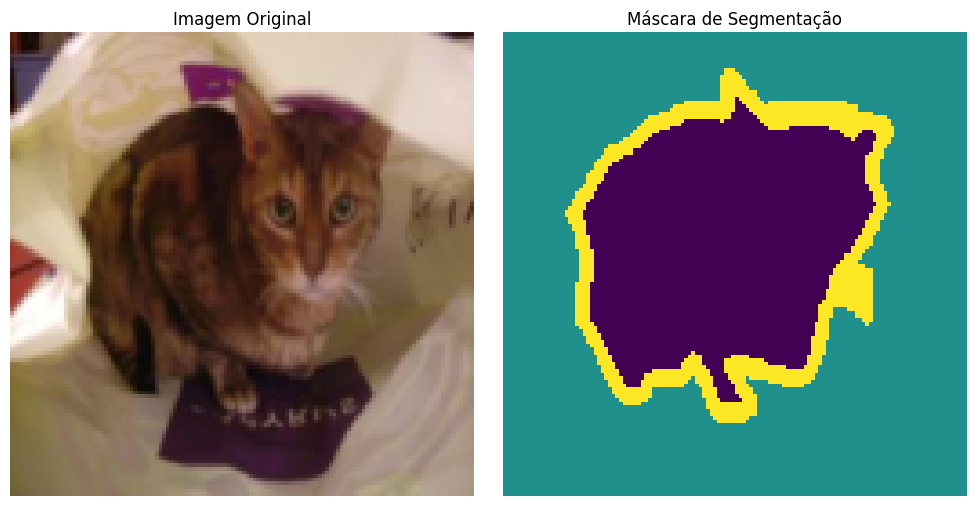

In [8]:
# Pegar um batch (lote) de dados do DataLoader de treino
images, masks = next(iter(train_loader))

# Selecionar a primeira imagem e a primeira máscara do batch
img = images[0]
mask = masks[0]

# O PyTorch armazena imagens no formato [Canais, Altura, Largura]
# O matplotlib exige o formato [Altura, Largura, Canais], então usamos o permute
img_np = img.permute(1, 2, 0).numpy()
mask_np = mask.numpy()

# Criar a figura para plotagem lado a lado
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plotar a imagem original
axes[0].imshow(img_np)
axes[0].set_title('Imagem Original')
axes[0].axis('off')

# Plotar a máscara de segmentação
# As cores na máscara representam as 3 classes do Oxford-IIIT Pet:
# Fundo, Interior do animal e Borda
axes[1].imshow(mask_np, cmap='viridis')
axes[1].set_title('Máscara de Segmentação')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### **2. Preparação do modelo UNet**

In [9]:
import torch.nn as nn
import torch.nn.functional as F

In [10]:
class DoubleConv(nn.Module):
    """Bloco auxiliar: (Conv2d -> BatchNorm -> ReLU) repetido 2 vezes"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=3):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        # Encoder (Descida)
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        # Decoder (Subida)
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(128, 64)

        # Camada de Saída (Output)
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        # Caminho do Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        # Caminho do Decoder com Skip Connections
        x = self.up1(x4)
        x = torch.cat([x, x3], dim=1) # Concatenando x com x3
        x = self.conv1(x)

        x = self.up2(x)
        x = torch.cat([x, x2], dim=1) # Concatenando x com x2
        x = self.conv2(x)

        x = self.up3(x)
        x = torch.cat([x, x1], dim=1) # Concatenando x com x1
        x = self.conv3(x)

        logits = self.outc(x)
        return logits

# Instanciando o modelo (3 canais de entrada RGB, 3 classes de saída)
# E movendo o modelo para a GPU (se disponível) para o treinamento ser rápido
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(n_channels=3, n_classes=3).to(device)

print(f"Modelo instanciado e alocado no dispositivo: {device}")

Modelo instanciado e alocado no dispositivo: cpu


### **3. Treinamento do Modelo**

### **3.1 Configuração do Otimizador (Adam), Função de Custo (loss) e Métricas (IoU e Acurácia)**

In [11]:
import torch.optim as optim
import torchmetrics

# Definindo a função de custo (Loss)
criterion = nn.CrossEntropyLoss()

# Definindo o otimizador (Adam com taxa de aprendizado de 0.001)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Definindo as métricas exigidas na atividade
# O dataset Oxford-IIIT Pet possui 3 classes (fundo, interior, borda)
num_classes = 3

# Acurácia
accuracy_metric = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(device)

# IoU (Intersection over Union), também chamado de Jaccard Index no torchmetrics
iou_metric = torchmetrics.JaccardIndex(task="multiclass", num_classes=num_classes).to(device)

print("✓ Otimizador, Função de Custo e Métricas configurados com sucesso.")

✓ Otimizador, Função de Custo e Métricas configurados com sucesso.


### **3.1 Laço de Treinamento e Validação (Training Loop)**

In [12]:
import time

num_epochs = 10

print("Iniciando o treinamento...")

for epoch in range(num_epochs):
    start_time = time.time()

    # -------------------------
    # FASE DE TREINAMENTO
    # -------------------------
    model.train() # Coloca o modelo em modo de treinamento
    train_loss = 0.0

    for images, masks in train_loader:
        # Move os dados para a GPU (se disponível)
        images = images.to(device)
        masks = masks.to(device)

        # Zera os gradientes acumulados
        optimizer.zero_grad()

        # Forward pass (predição do modelo)
        outputs = model(images)

        # Calcula o erro
        loss = criterion(outputs, masks)

        # Backward pass e atualização dos pesos
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss = train_loss / len(train_loader.dataset)

    # -------------------------
    # FASE DE VALIDAÇÃO
    # -------------------------
    model.eval() # Coloca o modelo em modo de avaliação (desliga dropout, etc)
    val_loss = 0.0

    # Reseta as métricas a cada época
    accuracy_metric.reset()
    iou_metric.reset()

    # torch.no_grad() desativa o cálculo de gradientes, poupando memória e tempo
    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item() * images.size(0)

            # As métricas esperam as classes preditas (índice com maior probabilidade)
            preds = torch.argmax(outputs, dim=1)

            # Atualiza as métricas com o lote atual
            accuracy_metric.update(preds, masks)
            iou_metric.update(preds, masks)

    val_loss = val_loss / len(test_loader.dataset)

    # Computa o valor final das métricas para a época
    val_acc = accuracy_metric.compute()
    val_iou = iou_metric.compute()

    end_time = time.time()
    epoch_duration = end_time - start_time

    # Imprime os resultados da época
    print(f"Época {epoch+1}/{num_epochs} | Duração: {epoch_duration:.2f}s")
    print(f"  Treino Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Val Acurácia: {val_acc:.4f} | Val IoU: {val_iou:.4f}")
    print("-" * 50)

print("Treinamento finalizado!")

Iniciando o treinamento...
Época 1/10 | Duração: 467.77s
  Treino Loss: 0.8129
  Val Loss: 1.0748 | Val Acurácia: 0.5924 | Val IoU: 0.3088
--------------------------------------------------
Época 2/10 | Duração: 468.53s
  Treino Loss: 0.6701
  Val Loss: 0.8064 | Val Acurácia: 0.6863 | Val IoU: 0.3907
--------------------------------------------------
Época 3/10 | Duração: 466.73s
  Treino Loss: 0.6284
  Val Loss: 0.7209 | Val Acurácia: 0.7131 | Val IoU: 0.4287
--------------------------------------------------
Época 4/10 | Duração: 462.60s
  Treino Loss: 0.6282
  Val Loss: 0.8074 | Val Acurácia: 0.6480 | Val IoU: 0.3900
--------------------------------------------------
Época 5/10 | Duração: 464.52s
  Treino Loss: 0.6006
  Val Loss: 0.7444 | Val Acurácia: 0.6998 | Val IoU: 0.4186
--------------------------------------------------
Época 6/10 | Duração: 466.58s
  Treino Loss: 0.5775
  Val Loss: 0.6966 | Val Acurácia: 0.7199 | Val IoU: 0.4474
----------------------------------------------

### **4. Exportando o Modelo para Mobile (TorchScript)**

In [13]:
import torch

# 1. Colocar o modelo em modo de avaliação (crucial para desativar Dropout/BatchNorm)
model.eval()

# 2. Mover o modelo para a CPU (a inferência no celular normalmente ocorre na CPU)
model.to('cpu')

# 3. Criar um tensor de exemplo no formato esperado pela rede (1 imagem, 3 canais, 128x128)
# O dtype=torch.float32 garante a exigência do FP32 da atividade
example_input = torch.rand(1, 3, 128, 128, dtype=torch.float32)

# 4. Rastrear (Trace) o modelo com o TorchScript
traced_script_module = torch.jit.trace(model, example_input)

# 5. Salvar o arquivo
model_path = "unet_pet_fp32.pt"
traced_script_module.save(model_path)

print(f"✓ Modelo exportado com sucesso para: {model_path}")

✓ Modelo exportado com sucesso para: unet_pet_fp32.pt
